# Web Scraping Example

[Web scraping](https://en.wikipedia.org/wiki/Web_scraping) means extracting data from a HTML user interface. Whether this is difficult or not depends on the HTML code of the page we want to scrape. Here, we use the BeautifulSoup library to help us parse the HTML and requests to load the remote page.

To find the correct HTML, we need to inspect the web page. [Ars Technica](https://arstechnica.com) is an awesome website, but at first glance it's quite complicated to parse. We need to use our browsers inspector to find the right HTML elements. It seems that each article is in a ```<article>...</article>``` structure, so that is nice:

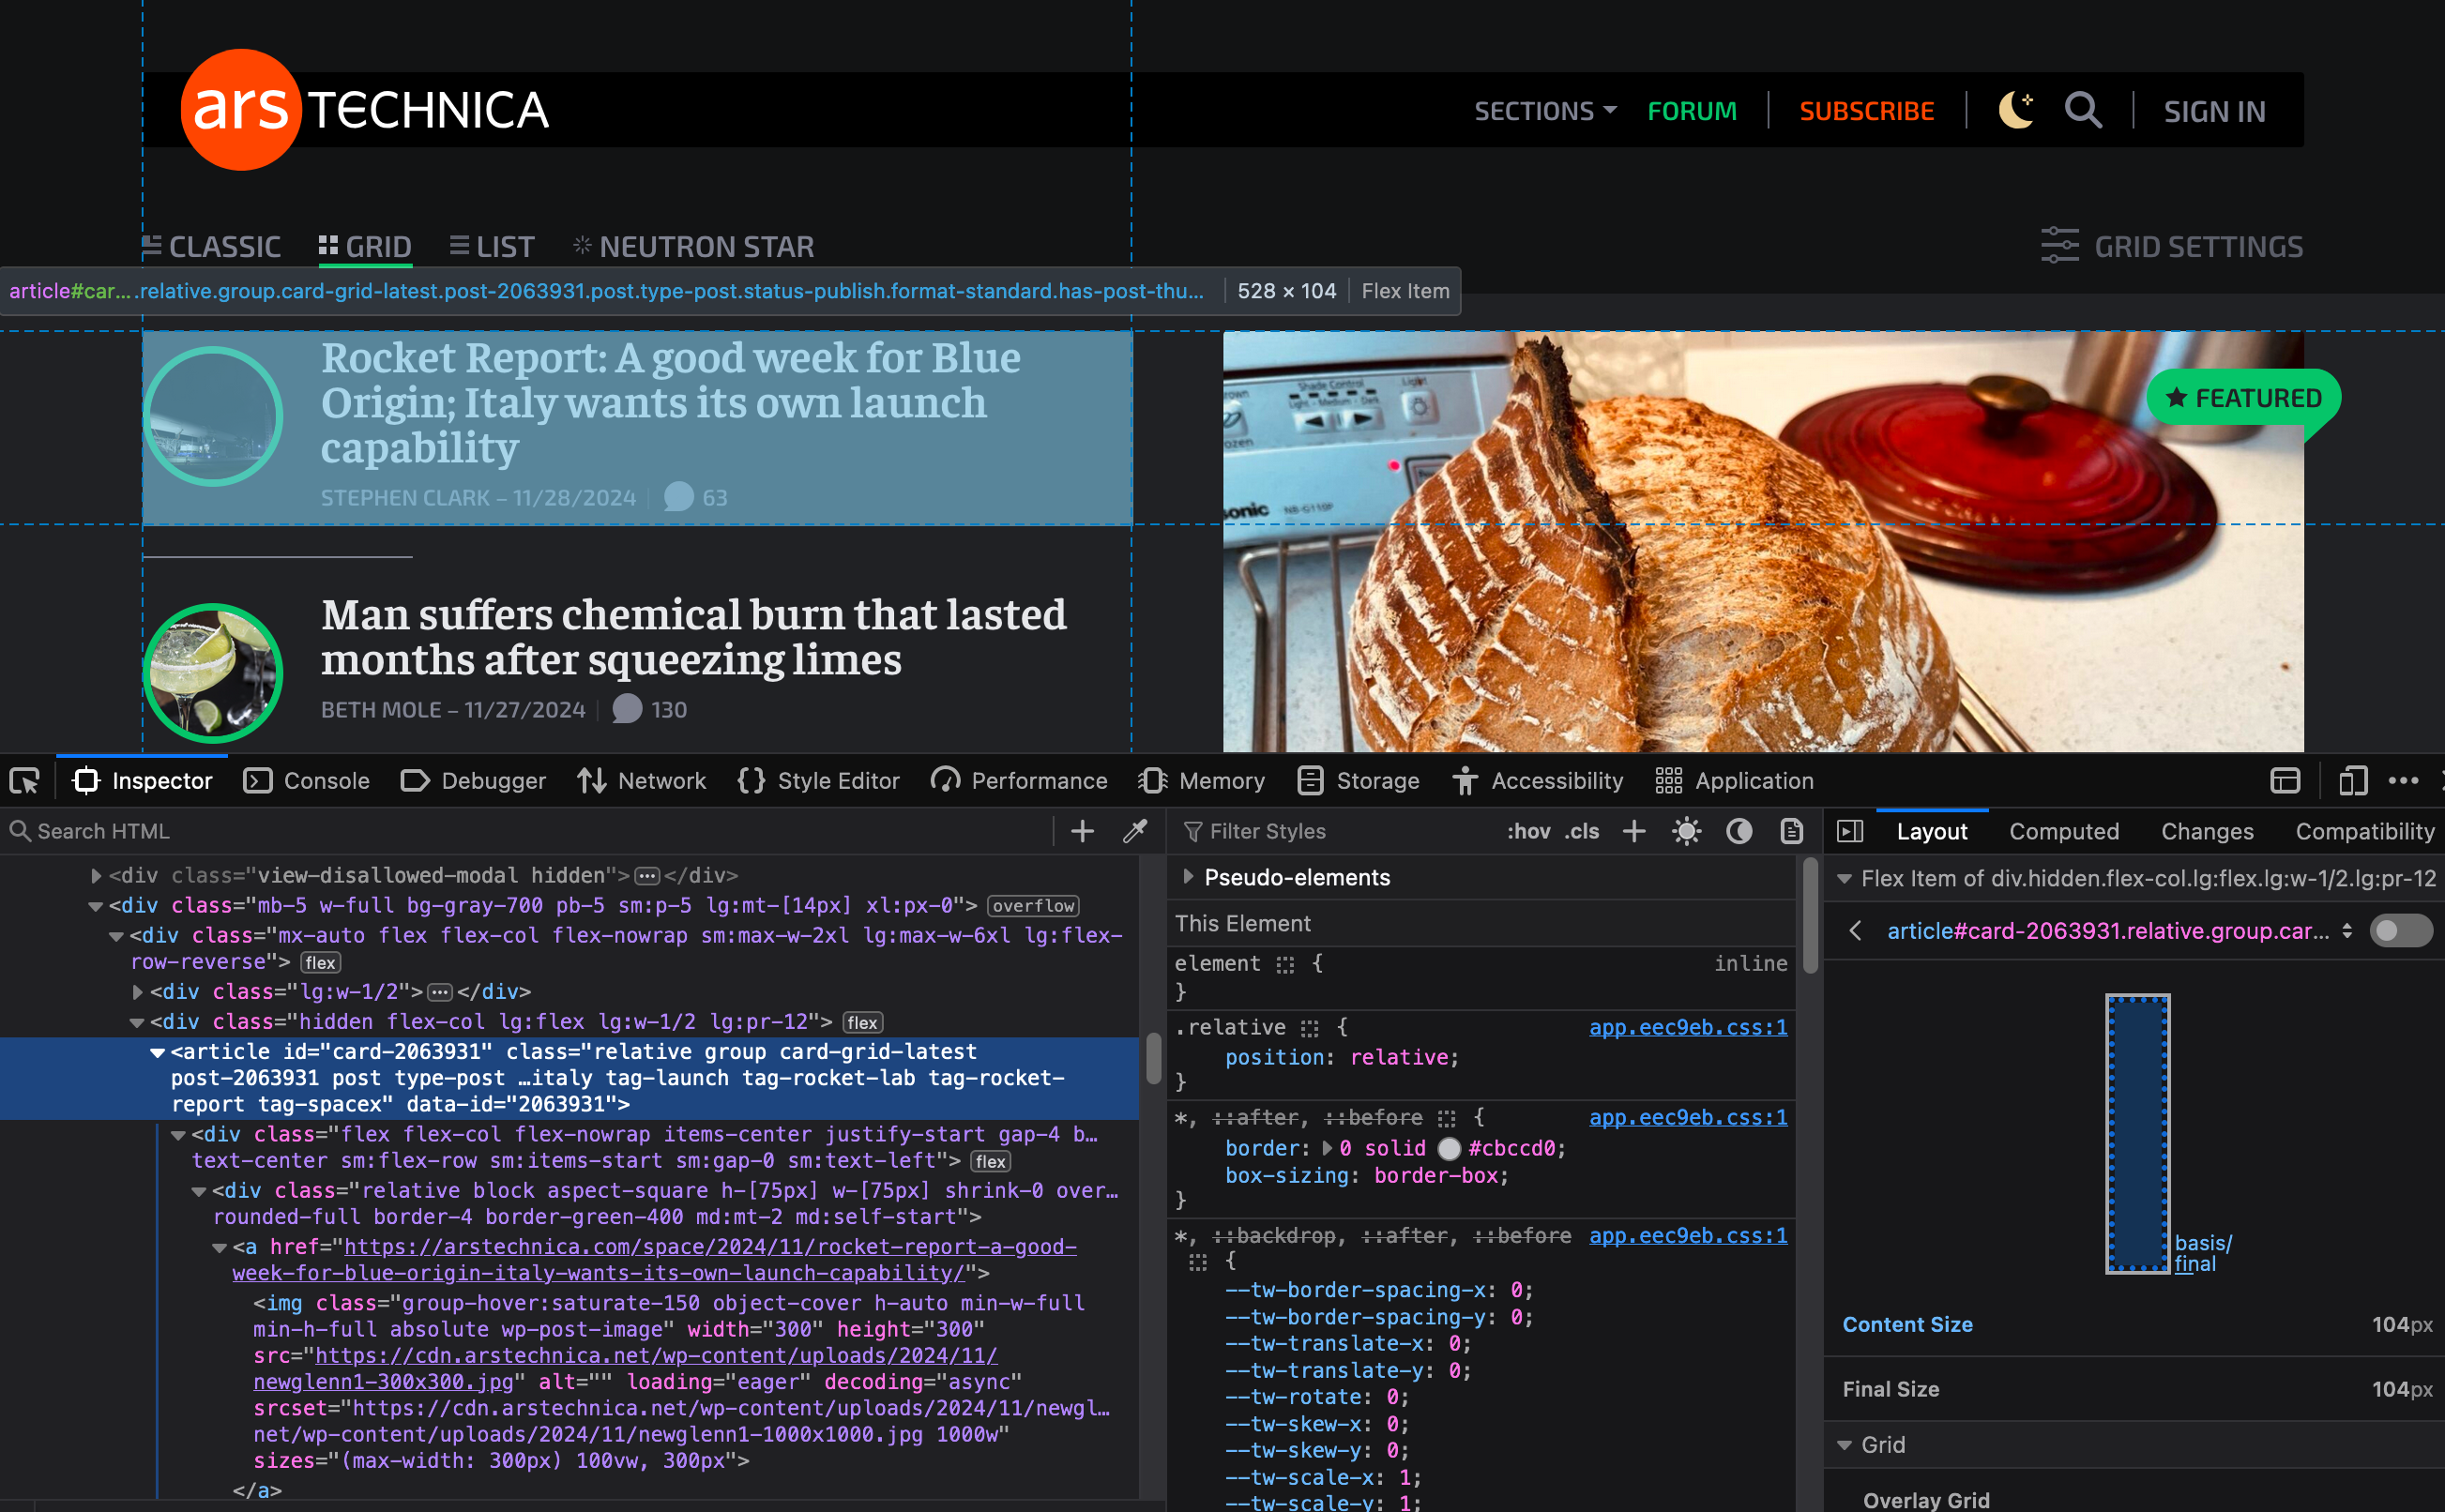

So we are using the requests library for loading the page and BeautifulSoup to help us parse the HTML.

In [6]:
import requests
from bs4 import BeautifulSoup

# URL of Ars Technica
url = 'https://research.rkd.nl/nl/detail/https%3A%2F%2Fdata.rkd.nl%2Fimages%2F216561?c=q%3D%26filters%255B0%255D%255Bfield%255D%3Ddb%26filters%255B0%255D%255Bvalues%255D%255B0%255D%3Drkdimages%26filters%255B0%255D%255Btype%255D%3Dall%26filters%255B1%255D%255Bfield%255D%3Dcreated%26filters%255B1%255D%255Bvalues%255D%255B0%255D%255Bfrom%255D%3D1600%26filters%255B1%255D%255Bvalues%255D%255B0%255D%255Bto%255D%3D1699%26filters%255B1%255D%255Btype%255D%3Dall%26filters%255B2%255D%255Bfield%255D%3Dkeyword%26filters%255B2%255D%255Bvalues%255D%255B0%255D%3Dhttps%253A%252F%252Fdata.rkd.nl%252Fthesaurus%252F62985%26filters%255B2%255D%255Btype%255D%3Dall%26filters%255B3%255D%255Bfield%255D%3Dcreator%26filters%255B3%255D%255Bvalues%255D%255B0%255D%3Dhttps%253A%252F%252Fdata.rkd.nl%252Fartists%252F39452%26filters%255B3%255D%255Bvalues%255D%255B1%255D%3Dhttps%253A%252F%252Fdata.rkd.nl%252Fartists%252F74809%26filters%255B3%255D%255Bvalues%255D%255B2%255D%3Dhttps%253A%252F%252Fdata.rkd.nl%252Fartists%252F66219%26filters%255B3%255D%255Bvalues%255D%255B3%255D%3Dhttps%253A%252F%252Fdata.rkd.nl%252Fartists%252F59178%26filters%255B3%255D%255Bvalues%255D%255B4%255D%3Dhttps%253A%252F%252Fdata.rkd.nl%252Fartists%252F23986%26filters%255B3%255D%255Bvalues%255D%255B5%255D%3Dhttps%253A%252F%252Fdata.rkd.nl%252Fartists%252F39579%26filters%255B3%255D%255Bvalues%255D%255B6%255D%3Dhttps%253A%252F%252Fdata.rkd.nl%252Fartists%252F36848%26filters%255B3%255D%255Bvalues%255D%255B7%255D%3Dhttps%253A%252F%252Fdata.rkd.nl%252Fartists%252F73980%26filters%255B3%255D%255Bvalues%255D%255B8%255D%3Dhttps%253A%252F%252Fdata.rkd.nl%252Fartists%252F52219%26filters%255B3%255D%255Bvalues%255D%255B9%255D%3Dhttps%253A%252F%252Fdata.rkd.nl%252Fartists%252F36847%26filters%255B3%255D%255Bvalues%255D%255B10%255D%3Dhttps%253A%252F%252Fdata.rkd.nl%252Fartists%252F55549%26filters%255B3%255D%255Btype%255D%3Dall&n=i%3D0%26p%3D1%26rpp%3D20%26tp%3D32#Toeschrijvingdatering'
# send a GET request to the website
response = requests.get(url)

# create a data structure where we'll store our articles
artworks = []

# check if the request was successful
if response.status_code == 200:

    # parse the HTML content
    soup = BeautifulSoup(response.content, 'html.parser')

    # find all article titles and links
    artworks = soup.find_all('article')

    # loop over all articles and put each article into our data structure
    for div in divs:
        main_text = div.find('toesc').find('a').text
        artworks.append({'main_texy': main_text})
else:
    print(f'Failed to retrieve the page. Status code: {response.status_code}')

display(artworks)

Failed to retrieve the page. Status code: 403


[]

As in the Web-API example, we could now save this, or loop over all article links to get the full text, etc. For example, this is a function to get one article:

In [ ]:
def getarticle(url):

  # send a GET request to the website
  response = requests.get(url)

  # create a data structure where we'll store our articles
  article = {}

  # check if the request was successful
  if response.status_code == 200:

      # parse the HTML content
      soup = BeautifulSoup(response.content, 'html.parser')

      # get the content
      article["title"] = soup.find('h1').text.strip()
      article["subtitle"] = soup.find('p', class_="text-gray-550").text.strip()
      article["content"] = soup.find('article').text.strip()

  else:
      print(f'Failed to retrieve the page. Status code: {response.status_code}')

  return article

And now we could loop over the article list to get all articles:

In [ ]:
# loop over the article list to get all articles
fullarticles = []

for article in myarticles:
  article = getarticle(article['link'])
  fullarticles.append(article)
  break   # break the loop after the first article, we don't want to hammer the site

display(fullarticles)